In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import AutoMinorLocator

folder_path = "."

def read_spectrum(file_path):
    df = pd.read_csv(file_path, skiprows=1)
    df = df.rename(columns={"WL/nm": "wavelength_nm", "Abs": "absorbance"})
    return df[["wavelength_nm", "absorbance"]].dropna().reset_index(drop=True)

def find_local_maxima(df, n_peaks=1, min_distance_nm=20, peak_range=None):
    peaks = get_local_maxima(df, peak_range=peak_range)
    selected = []
    for peak_x, peak_y in peaks:
        if all(abs(peak_x - selected_x) >= min_distance_nm for selected_x, _ in selected):
            selected.append((peak_x, peak_y))
        if len(selected) >= n_peaks:
            break
    return selected


In [2]:
# Получаем список всех CSV-файлов в папке
csv_files = []

for file_name in os.listdir('.'):
    if file_name.endswith(".csv"):
        csv_files.append(file_name)

for file_name in csv_files:
    print(file_name)

AUPVP1.csv
AUCOAG2.csv
AG1_1.csv
AG2SUC1.csv
PT2.csv
PT_1.csv
AG2_1.csv
AG2SUC2.csv
AUSUC1.csv
AUCOAG.csv
AU1.csv
AGCOAG.csv
AUSUC2.csv


In [3]:
def get_local_maxima(df, peak_range=None):
    """
    Возвращает все локальные максимумы, отсортированные по убыванию поглощения.

    Parameters
    ----------
    df : pandas.DataFrame
        Таблица с колонками wavelength_nm и absorbance.
    peak_range : tuple or None
        Диапазон поиска (left, right) в нм.

    Returns
    -------
    list of tuples
        Список пиков [(x1, y1), (x2, y2), ...],
        отсортированный по убыванию y.
    """
    df_work = df.copy()

    if peak_range is not None:
        left, right = peak_range
        df_work = df_work[
            (df_work["wavelength_nm"] >= left) &
            (df_work["wavelength_nm"] <= right)
        ].reset_index(drop=True)

    if len(df_work) < 3:
        return []

    x = df_work["wavelength_nm"].values
    y = df_work["absorbance"].values

    local_peaks = []

    for i in range(1, len(y) - 1):
        if y[i] > y[i - 1] and y[i] > y[i + 1]:
            local_peaks.append((x[i], y[i]))

    local_peaks = sorted(local_peaks, key=lambda p: p[1], reverse=True)
    return local_peaks

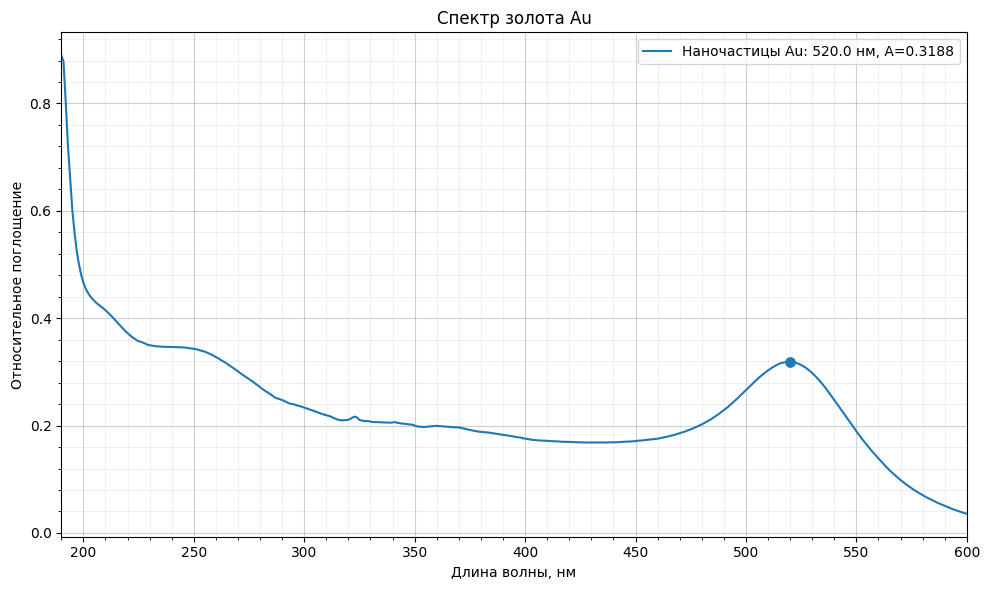

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

file_name = "AU1.csv"
file_path = os.path.join(folder_path, file_name)

df = read_spectrum(file_path)
df = df[df["wavelength_nm"] <= 600].reset_index(drop=True)

peaks = find_local_maxima(
    df,
    n_peaks=1,
    min_distance_nm=20,
    peak_range=(450, 580)
)

peak_text = "; ".join([
    f"{peak_x:.1f} нм, A={peak_y:.4f}"
    for peak_x, peak_y in peaks
])

ax.plot(
    df["wavelength_nm"],
    df["absorbance"],
    linewidth=1.5,
    label=f"Наночастицы Au: {peak_text}",
    zorder=2
)

for peak_x, peak_y in peaks:
    ax.scatter(peak_x, peak_y, s=45, zorder=3)

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектр золота Au")

ax.set_xlim(df["wavelength_nm"].min(), 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_1.pdf", bbox_inches="tight")


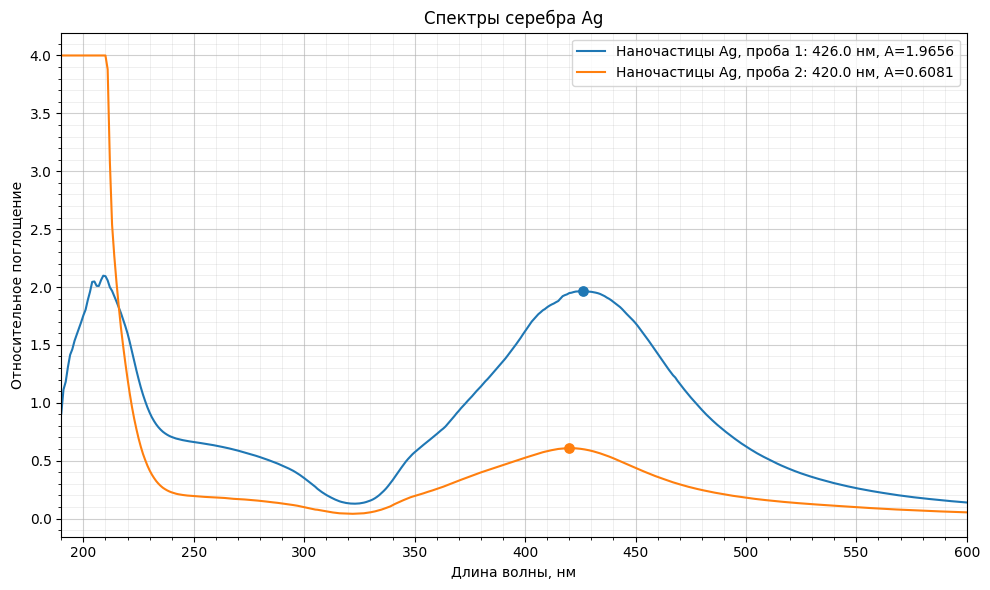

In [115]:
fig, ax = plt.subplots(figsize=(10, 6))

silver_files = ["AG1_1.csv", "AG2_1.csv"]

x_min = 600

for file_name in silver_files:
    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[df["wavelength_nm"] <= 600].reset_index(drop=True)

    x_min = min(x_min, df["wavelength_nm"].min())

    all_peaks = get_local_maxima(df)

    if file_name == "AG1_1.csv":
        sample_label = "Наночастицы Ag, проба 1"

        if len(all_peaks) >= 3:
            peaks = [all_peaks[2]]
        elif len(all_peaks) >= 1:
            peaks = [all_peaks[0]]
        else:
            peaks = []

    else:
        sample_label = "Наночастицы Ag, проба 2"

        if len(all_peaks) >= 1:
            peaks = [all_peaks[0]]
        else:
            peaks = []

    peak_text = "; ".join([
        f"{peak_x:.1f} нм, A={peak_y:.4f}"
        for peak_x, peak_y in peaks
    ])

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=f"{sample_label}: {peak_text}",
        zorder=2
    )

    for peak_x, peak_y in peaks:
        ax.scatter(peak_x, peak_y, s=45, zorder=3)

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры серебра Ag")

ax.set_xlim(x_min, 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_2.pdf", bbox_inches="tight")


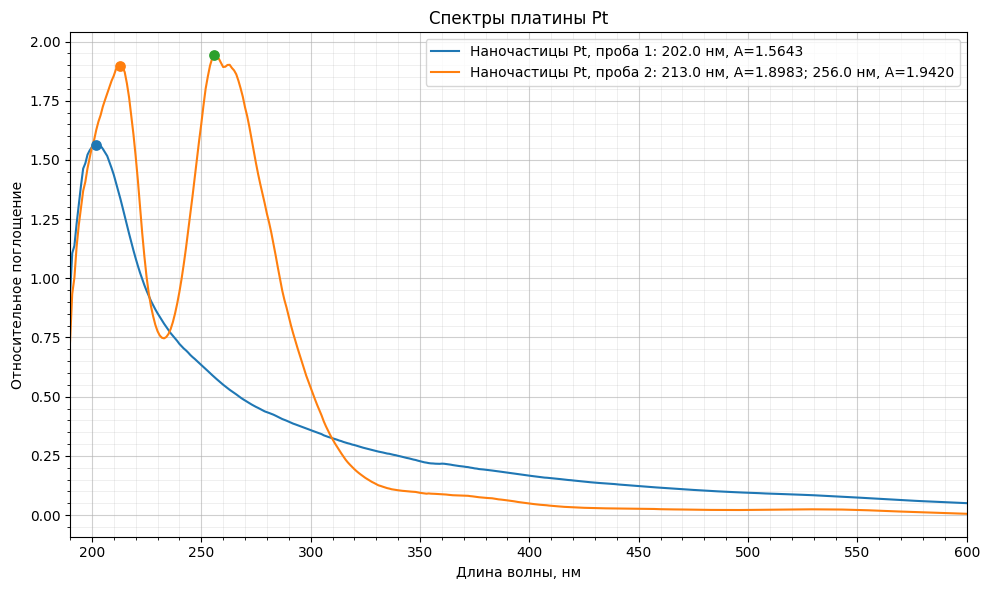

In [116]:
fig, ax = plt.subplots(figsize=(10, 6))

platinum_files = ["PT_1.csv", "PT2.csv"]

x_min = 600

for file_name in platinum_files:
    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[df["wavelength_nm"] <= 600].reset_index(drop=True)

    x_min = min(x_min, df["wavelength_nm"].min())

    all_peaks = get_local_maxima(df)

    if file_name == "PT_1.csv":
        sample_label = "Наночастицы Pt, проба 1"

        # Для Pt1 берем только один максимум
        peaks = all_peaks[:1]

    else:
        sample_label = "Наночастицы Pt, проба 2"

        # Для Pt2 берем 1-й и 3-й пики
        peaks = []

        if len(all_peaks) >= 1:
            peaks.append(all_peaks[0])

        if len(all_peaks) >= 3:
            peaks.append(all_peaks[2])
        elif len(all_peaks) >= 2:
            peaks.append(all_peaks[1])

    peaks = sorted(peaks, key=lambda p: p[0])

    peak_text = "; ".join([
        f"{peak_x:.1f} нм, A={peak_y:.4f}"
        for peak_x, peak_y in peaks
    ])

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=f"{sample_label}: {peak_text}",
        zorder=2
    )

    for peak_x, peak_y in peaks:
        ax.scatter(peak_x, peak_y, s=45, zorder=3)

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры платины Pt")

ax.set_xlim(x_min, 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_3.pdf", bbox_inches="tight")


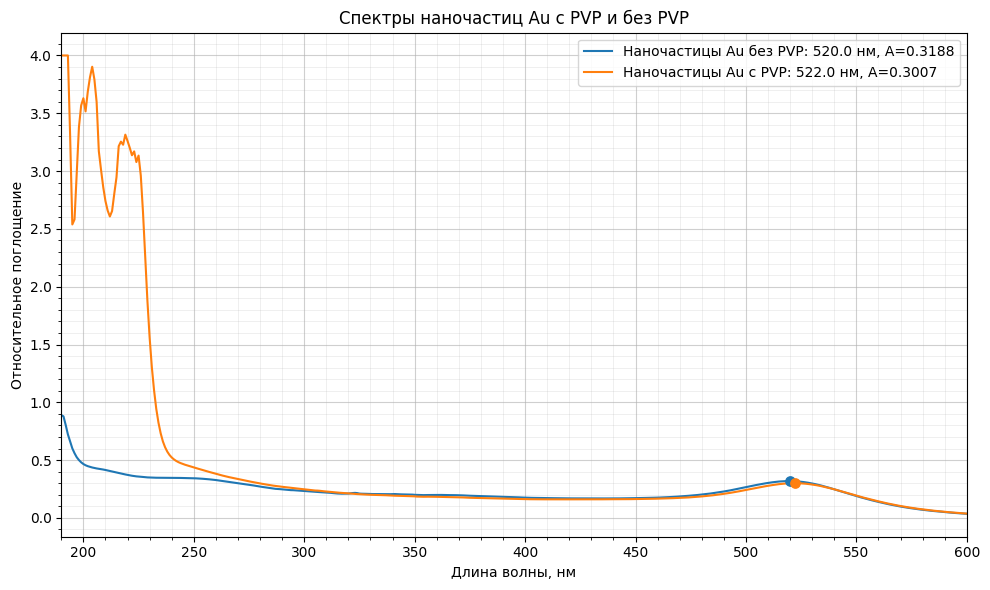

In [117]:
fig, ax = plt.subplots(figsize=(10, 6))

au_files = {
    "Наночастицы Au без PVP": {
        "file": "AU1.csv",
        "peak_range": (450, 580)
    },
    "Наночастицы Au с PVP": {
        "file": "AUPVP1.csv",
        "peak_range": (450, 580)
    }
}

x_min = 600

for sample_name, info in au_files.items():
    file_name = info["file"]
    peak_range = info["peak_range"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[df["wavelength_nm"] <= 600].reset_index(drop=True)

    x_min = min(x_min, df["wavelength_nm"].min())

    all_peaks = get_local_maxima(df, peak_range=peak_range)

    if len(all_peaks) >= 1:
        peaks = [all_peaks[0]]
    else:
        peaks = []

    peak_text = "; ".join([
        f"{peak_x:.1f} нм, A={peak_y:.4f}"
        for peak_x, peak_y in peaks
    ])

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=f"{sample_name}: {peak_text}",
        zorder=2
    )

    for peak_x, peak_y in peaks:
        ax.scatter(
            peak_x,
            peak_y,
            s=45,
            zorder=3
        )

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Au с PVP и без PVP")

ax.set_xlim(x_min, 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_pvp.pdf", bbox_inches="tight")


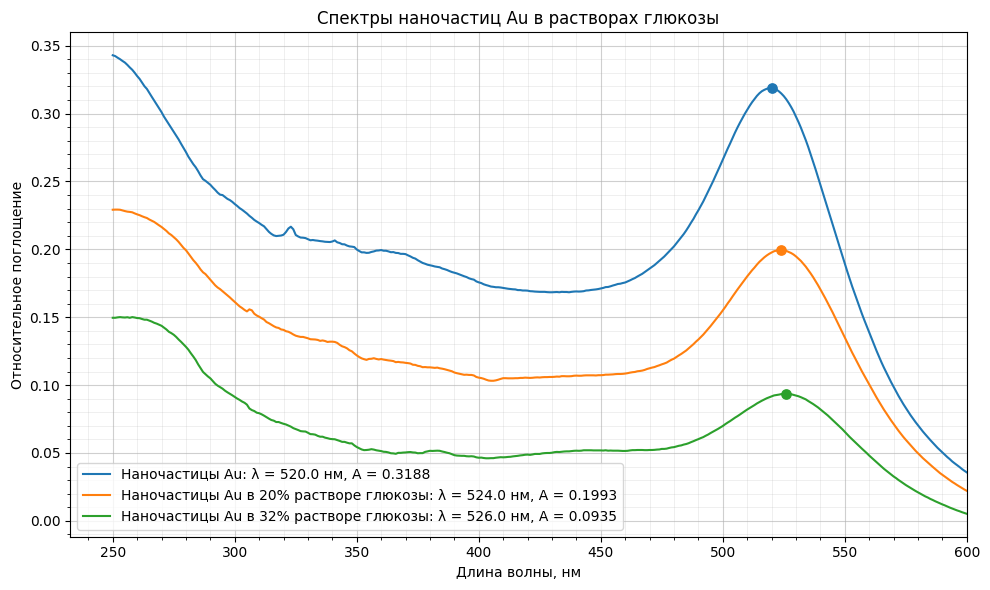

In [118]:
fig, ax = plt.subplots(figsize=(10, 6))

samples_au = {
    "Наночастицы Au": {
        "file": "AU1.csv",
        "peak_range": (450, 580)
    },
    "Наночастицы Au в 20% растворе глюкозы": {
        "file": "AUSUC1.csv",
        "peak_range": (450, 580)
    },
    "Наночастицы Au в 32% растворе глюкозы": {
        "file": "AUSUC2.csv",
        "peak_range": (450, 580)
    }
}

for sample_name, info in samples_au.items():
    file_name = info["file"]
    peak_range = info["peak_range"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[
        (df["wavelength_nm"] >= 250) &
        (df["wavelength_nm"] <= 600)
    ].reset_index(drop=True)

    all_peaks = get_local_maxima(df, peak_range=peak_range)

    if len(all_peaks) >= 1:
        peaks = [all_peaks[0]]
    else:
        peaks = []

    peak_text = "; ".join([
        f"λ = {peak_x:.1f} нм, A = {peak_y:.4f}"
        for peak_x, peak_y in peaks
    ])

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=f"{sample_name}: {peak_text}",
        zorder=2
    )

    for peak_x, peak_y in peaks:
        ax.scatter(peak_x, peak_y, s=45, zorder=3)

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Au в растворах глюкозы")

ax.set_xlim(right=600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_suc_au.pdf", bbox_inches="tight")


NameError: name 'wl_range' is not defined

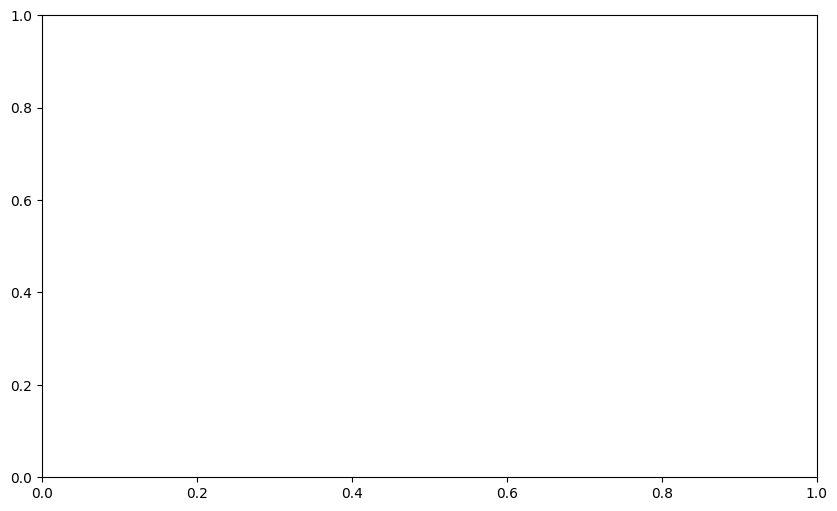

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

samples_au = {
    "Наночастицы Au": {
        "file": "AU1.csv",
        "peak_range": (450, 580),
        "n_theory": 1.33
    },
    "Наночастицы Au в 20% растворе глюкозы": {
        "file": "AUSUC1.csv",
        "peak_range": (450, 580),
        "n_theory": 1.361
    },
    "Наночастицы Au в 32% растворе глюкозы": {
        "file": "AUSUC2.csv",
        "peak_range": (450, 580),
        "n_theory": 1.3778
    }
}

wl_theory = np.array(wl_range)

for sample_name, info in samples_au.items():
    file_name = info["file"]
    peak_range = info["peak_range"]
    n_theory = info["n_theory"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[
        (df["wavelength_nm"] >= 250) &
        (df["wavelength_nm"] <= 600)
    ].reset_index(drop=True)

    all_peaks = get_local_maxima(df, peak_range=peak_range)

    if len(all_peaks) >= 1:
        peaks = [all_peaks[0]]
    else:
        peaks = []

    peak_text = "; ".join([
        f"λ = {peak_x:.1f} нм, A = {peak_y:.4f}"
        for peak_x, peak_y in peaks
    ])

    # Эксперимент
    exp_line, = ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=f"{sample_name}: {peak_text}",
        zorder=2
    )

    for peak_x, peak_y in peaks:
        ax.scatter(peak_x, peak_y, s=45, zorder=3)

    # Теоретический расчет
    absorption_theory = []

    for wl in wl_theory:
        e_metal = epsilon_apprx(wl, "Au")

        # Диэлектрическая проницаемость среды: epsilon = n^2
        e_sol = n_theory ** 2

        alpha_im = np.imag(
            (e_metal - e_sol) / (e_metal + 2 * e_sol)
        ) / 8

        absorption_theory.append(alpha_im)

    absorption_theory = np.array(absorption_theory)

    theory_mask = (
        (wl_theory >= 250) &
        (wl_theory <= 600)
    )

    wl_theory_plot = wl_theory[theory_mask]
    absorption_theory_plot = absorption_theory[theory_mask]

    theory_peak_idx = np.argmax(absorption_theory_plot)
    theory_peak_x = wl_theory_plot[theory_peak_idx]
    theory_peak_y = absorption_theory_plot[theory_peak_idx]

    ax.plot(
        wl_theory_plot,
        absorption_theory_plot,
        linewidth=1.5,
        linestyle="--",
        color=exp_line.get_color(),
        label=(
            f"Теория для n = {n_theory}: "
            f"λ = {theory_peak_x:.1f} нм, A = {theory_peak_y:.4f}"
        ),
        zorder=1
    )

    ax.scatter(
        theory_peak_x,
        theory_peak_y,
        s=45,
        marker="x",
        color=exp_line.get_color(),
        zorder=3
    )

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Au в растворах глюкозы")

ax.set_xlim(right=600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_suc_au.pdf", bbox_inches="tight")
plt.show()

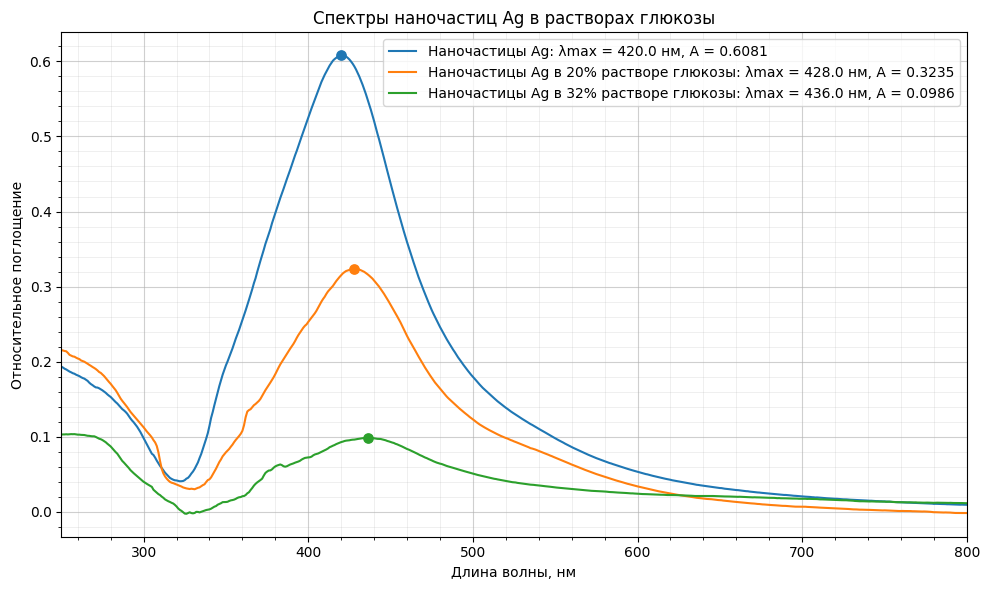

In [119]:
def get_peak_in_range(df, peak_range):
    """
    Находит максимум поглощения в заданном диапазоне длин волн.
    """
    left, right = peak_range

    df_work = df[
        (df["wavelength_nm"] >= left) &
        (df["wavelength_nm"] <= right)
    ].reset_index(drop=True)

    if df_work.empty:
        return []

    peak_idx = df_work["absorbance"].idxmax()

    peak_x = df_work.loc[peak_idx, "wavelength_nm"]
    peak_y = df_work.loc[peak_idx, "absorbance"]

    return [(peak_x, peak_y)]


fig, ax = plt.subplots(figsize=(10, 6))

samples_ag = {
    "Наночастицы Ag": {
        "file": "AG2_1.csv",
        "peak_range": (400, 500),
        "y_multiplier": 1
    },
    "Наночастицы Ag в 20% растворе глюкозы": {
        "file": "AG2SUC1.csv",
        "peak_range": (400, 500),
        "y_multiplier": 1
    },
    "Наночастицы Ag в 32% растворе глюкозы": {
        "file": "AG2SUC2.csv",
        "peak_range": (400, 500),
        "y_multiplier": 1
    }
}

for sample_name, info in samples_ag.items():
    file_name = info["file"]
    peak_range = info["peak_range"]
    y_multiplier = info["y_multiplier"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)

    df = df[
        (df["wavelength_nm"] >= 250) &
        (df["wavelength_nm"] <= 800)
    ].reset_index(drop=True)

    df["absorbance"] = df["absorbance"] * y_multiplier

    peaks = get_peak_in_range(df, peak_range)

    peak_text = "; ".join([
        f"λmax = {peak_x:.1f} нм, A = {peak_y:.4f}"
        for peak_x, peak_y in peaks
    ])

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=f"{sample_name}: {peak_text}",
        zorder=2
    )

    for peak_x, peak_y in peaks:
        ax.scatter(
            peak_x,
            peak_y,
            s=45,
            zorder=3
        )

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Ag в растворах глюкозы")

ax.set_xlim(250, 800)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_suc_ag.pdf", bbox_inches="tight")


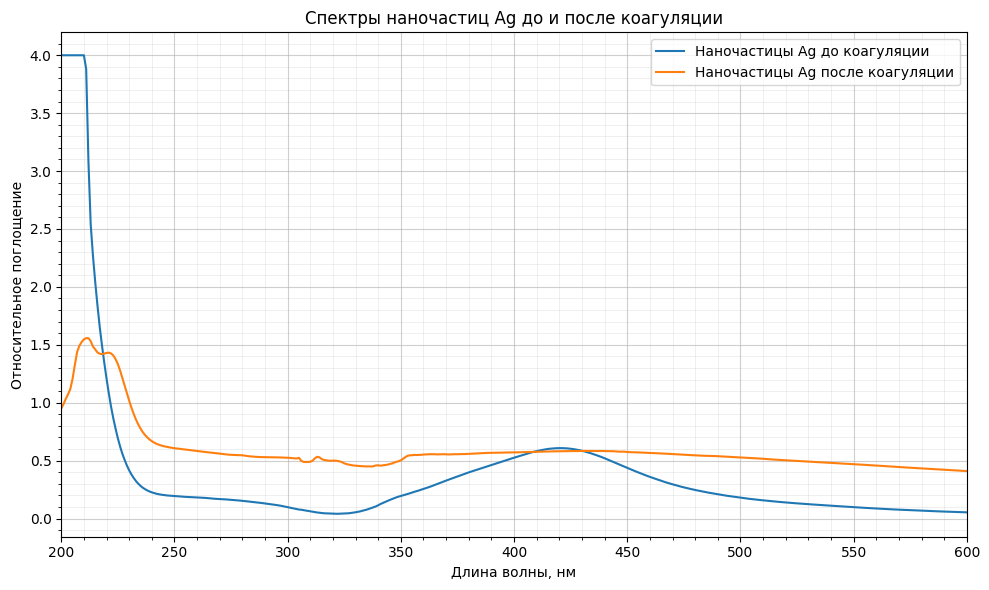

In [120]:
fig, ax = plt.subplots(figsize=(10, 6))

samples_ag_coag = {
    "Наночастицы Ag до коагуляции": {
        "file": "AG2_1.csv"
    },
    "Наночастицы Ag после коагуляции": {
        "file": "AGCOAG.csv"
    }
}

for sample_name, info in samples_ag_coag.items():
    file_name = info["file"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[
        (df["wavelength_nm"] >= 200) &
        (df["wavelength_nm"] <= 600)
    ].reset_index(drop=True)

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=sample_name,
        zorder=2
    )

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Ag до и после коагуляции")

ax.set_xlim(200, 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_ag_caug.pdf", bbox_inches="tight")


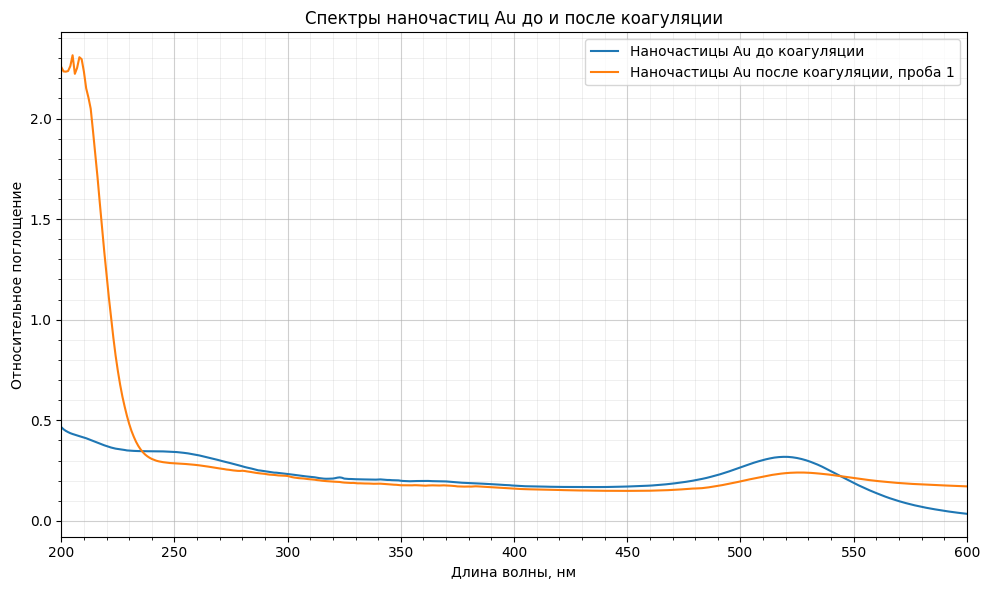

In [121]:
fig, ax = plt.subplots(figsize=(10, 6))

samples_au_coag_1 = {
    "Наночастицы Au до коагуляции": {
        "file": "AU1.csv"
    },
    "Наночастицы Au после коагуляции, проба 1": {
        "file": "AUCOAG.csv"
    }
}

for sample_name, info in samples_au_coag_1.items():
    file_name = info["file"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[
        (df["wavelength_nm"] >= 200) &
        (df["wavelength_nm"] <= 600)
    ].reset_index(drop=True)

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=sample_name,
        zorder=2
    )

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Au до и после коагуляции")

ax.set_xlim(200, 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_au_coag_1.pdf", bbox_inches="tight")


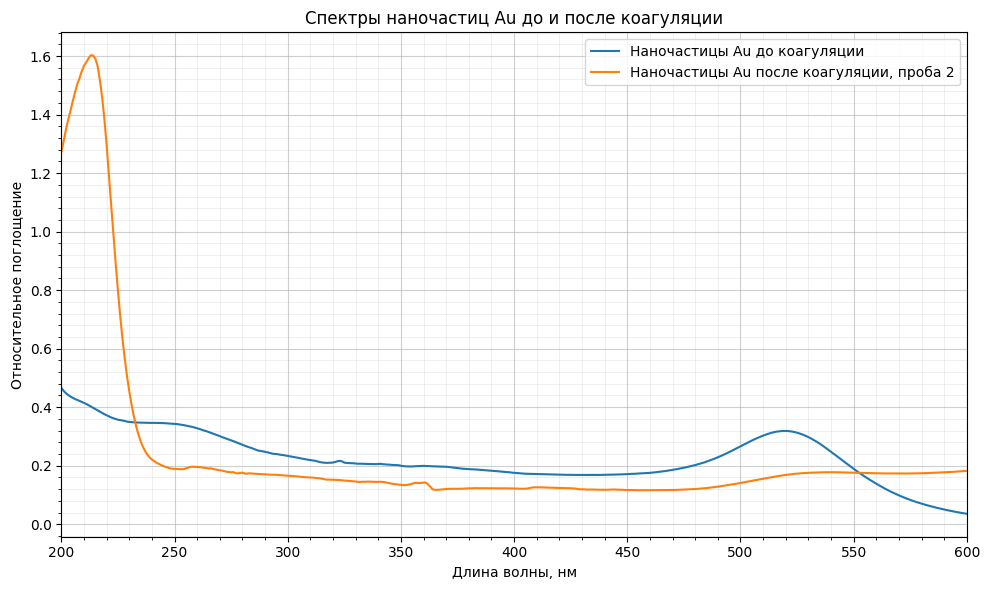

In [122]:
fig, ax = plt.subplots(figsize=(10, 6))

samples_au_coag_2 = {
    "Наночастицы Au до коагуляции": {
        "file": "AU1.csv"
    },
    "Наночастицы Au после коагуляции, проба 2": {
        "file": "AUCOAG2.csv"
    }
}

for sample_name, info in samples_au_coag_2.items():
    file_name = info["file"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[
        (df["wavelength_nm"] >= 200) &
        (df["wavelength_nm"] <= 600)
    ].reset_index(drop=True)

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=sample_name,
        zorder=2
    )

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Au до и после коагуляции")

ax.set_xlim(200, 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_au_coag_2.pdf", bbox_inches="tight")


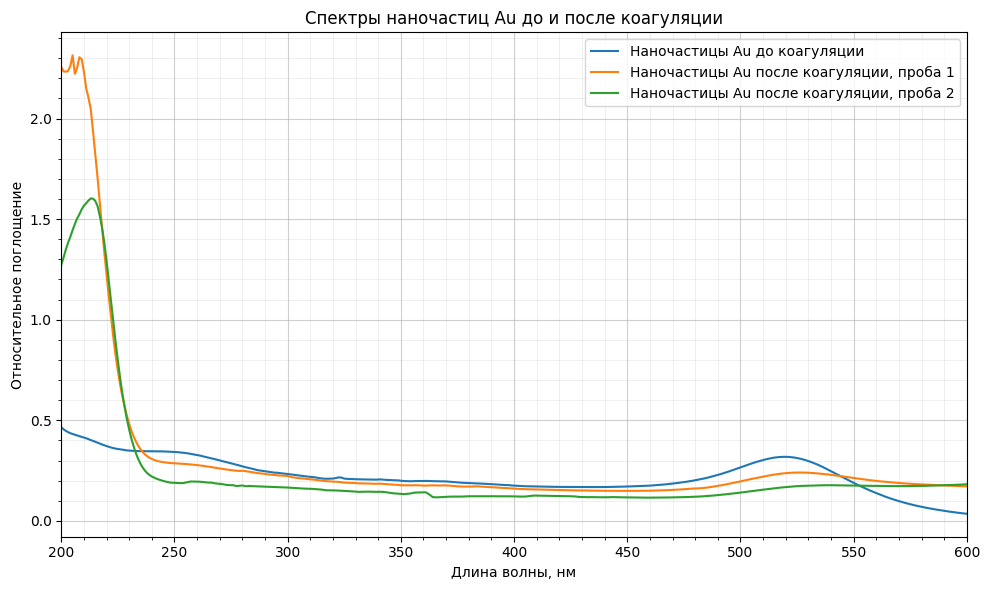

In [123]:
fig, ax = plt.subplots(figsize=(10, 6))

samples_au_coag_all = {
    "Наночастицы Au до коагуляции": {
        "file": "AU1.csv"
    },
    "Наночастицы Au после коагуляции, проба 1": {
        "file": "AUCOAG.csv"
    },
    "Наночастицы Au после коагуляции, проба 2": {
        "file": "AUCOAG2.csv"
    }
}

for sample_name, info in samples_au_coag_all.items():
    file_name = info["file"]

    file_path = os.path.join(folder_path, file_name)

    df = read_spectrum(file_path)
    df = df[
        (df["wavelength_nm"] >= 200) &
        (df["wavelength_nm"] <= 600)
    ].reset_index(drop=True)

    ax.plot(
        df["wavelength_nm"],
        df["absorbance"],
        linewidth=1.5,
        label=sample_name,
        zorder=2
    )

ax.set_xlabel("Длина волны, нм")
ax.set_ylabel("Относительное поглощение")
ax.set_title("Спектры наночастиц Au до и после коагуляции")

ax.set_xlim(200, 600)

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.35)

ax.legend()
plt.tight_layout()
fig.savefig("graph_au_coag_all.pdf", bbox_inches="tight")


NameError: name 'wl_range' is not defined